In [2]:
#@title KONFIGURACJA ŚRODOWISKA + IMPORTY

import os
import sys

# 1. Dodajemy folder główny projektu do ścieżki Pythona
# '..' oznacza "wyjdź jeden folder wyżej" (z /notebooks do folderu głównego)
sciezka_glowna = os.path.abspath('..')
if sciezka_glowna not in sys.path:
    sys.path.append(sciezka_glowna)

# 2. Importujemy nasze narzędzia z pliku pipeline/utils.py
from pipeline.utils import (
    wczytaj_dane,
    polacz_dane,
    usun_outliery,
    usun_nan,
    czyszczenie_procenty,
    skategoryzuj_kolumne_numeryczna,
    filtruj_dane,
    top10_wartosci,
    wykres_liniowy,
    wykres_punktowy,
    wykres_babelkowy,
    wykres_korelacji,
    tabela_korelacji,
    wykres_kolowy,
    wykres_histogram
)

# 3. Przydatne biblioteki dla samego notatnika
import pandas as pd

# 4. Magiczna komenda dla notatników Jupyter (pozwala wyświetlać wykresy wewnątrz notatnika)
%matplotlib inline

print("Narzędzia gotowe do pracy! 🚀")

Narzędzia gotowe do pracy! 🚀


In [ ]:
# 1. Definiujemy bazowy link do folderu "data" w wersji RAW na GitHubie
BAZA_URL = "https://raw.githubusercontent.com/tadejow/warsztaty-wizualizacja-danych/main/data/"

print("Rozpoczynam pobieranie i czyszczenie danych...\n")

# 2. Wczytujemy wszystkie pliki do osobnych zmiennych (tzw. ramek danych - DataFrame)
df_costs     = wczytaj_dane(BAZA_URL + "costs_of_living_index.csv")
df_crime     = wczytaj_dane(BAZA_URL + "crime_index.csv")
df_economy   = wczytaj_dane(BAZA_URL + "economy_index.csv")
df_happiness = wczytaj_dane(BAZA_URL + "happiness_index.csv")
df_health    = wczytaj_dane(BAZA_URL + "health_index.csv")
df_pollution = wczytaj_dane(BAZA_URL + "pollution_index.csv")
df_property  = wczytaj_dane(BAZA_URL + "property_price_index.csv")
df_quality   = wczytaj_dane(BAZA_URL + "quality_of_life_index.csv")
df_traffic   = wczytaj_dane(BAZA_URL + "traffic_index.csv")
df_world     = wczytaj_dane(BAZA_URL + "world_data.csv")

print("\n✅ Wszystkie 10 zbiorów danych zostało pomyślnie wczytane i wstępnie oczyszczone!")

In [8]:
df_happiness

,year,country,life_evaluation,change_since_2012,inequality,social_support,gdp_per_capita,healthy_life_expectancy,freedom,generosity,perceptions_of_corruption,positive_emotions,negative_emotions,donated,volunteered,helped_a_stranger,healthy_life_expectancy_2021_data
0,2011,Denmark,7.856,NaN,11.0,4.0,9.0,22.0,9.0,7.0,3.0,16.0,29.0,7.0,45.0,45.0,NaN
1,2011,Finland,7.579,NaN,17.0,12.0,15.0,23.0,7.0,22.0,7.0,47.0,50.0,22.0,31.0,29.0,NaN
2,2011,Netherlands,7.512,NaN,2.0,11.0,6.0,NaN,14.0,3.0,10.0,18.0,37.0,3.0,15.0,48.0,NaN
3,2011,Canada,7.499,NaN,53.0,20.0,17.0,11.0,3.0,11.0,13.0,9.0,76.0,11.0,6.0,11.0,NaN
4,2011,Sweden,7.379,NaN,14.0,22.0,13.0,4.0,5.0,16.0,5.0,21.0,32.0,16.0,97.0,57.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1956,2024,Botswana,3.438,-0.532,119.0,110.0,63.0,NaN,86.0,125.0,81.0,75.0,67.0,125.0,95.0,10.0,NaN
1957,2024,Zimbabwe,3.396,-1.431,94.0,127.0,119.0,NaN,120.0,139.0,49.0,101.0,29.0,139.0,92.0,106.0,115.0
1958,2024,Malawi,3.260,-0.853,132.0,140.0,132.0,NaN,105.0,103.0,47.0,123.0,95.0,103.0,26.0,12.0,106.0
1959,2024,Lebanon,3.188,-1.743,73.0,90.0,87.0,NaN,137.0,94.0,111.0,141.0,122.0,94.0,136.0,134.0,66.0


## 📂 Sekcja 1: Przygotowanie i Czyszczenie Danych

Mamy wczytane dane, ale są one rozsiane po 10 różnych tabelach. Aby znaleźć ciekawe zależności (np. czy bogactwo kraju wpływa na poziom szczęścia obywateli?), musimy **połączyć tabele**, a następnie usunąć z nich błędy i braki.

In [17]:
# 1. ŁĄCZENIE DANYCH (polacz_dane)
# Łączymy ogólne dane o świecie (df_world) ze wskaźnikiem szczęścia (df_happiness)
# Obie tabele na pewno mają kolumnę z nazwą kraju - użyjemy jej jako klucza.
print("--- Łączenie tabel ---")
df_merged = polacz_dane(dane1=df_world, dane2=df_happiness, klucz='country')

# 2. USUWANIE BRAKÓW DANYCH (usun_nan)
# Sprawdzamy, czy w połączonej tabeli mamy wynik szczęścia. Jeśli go brakuje, wiersz jest bezużyteczny.
print("\n--- Usuwanie braków (NaN) ---")
# UWAGA: Upewnij się, jak dokładnie nazywa się kolumna ze wskaźnikiem szczęścia po połączeniu!
# Załóżmy, że nazywa się 'happiness_score'
df_bez_brakow = usun_nan(dane=df_merged, kolumna='life_evaluation')

# 3. USUWANIE OUTLIERÓW (usun_outliery)
# Czasami w danych trafiają się anomalie (np. mikropaństwa z dziwnym PKB). Usuniemy je.
print("\n--- Usuwanie wartości odstających (Outlierów) ---")
# Sprawdzamy wybrane kolumny (zmień nazwy, jeśli w plikach są inne)
df_clean = usun_outliery(dane=df_bez_brakow, kolumny=['inequality', 'gdp_per_capita'])

# Gotowe! Zobaczmy ile wierszy nam zostało do analizy:
print(f"\nLiczba wierszy po czyszczeniu: {len(df_clean)}")

--- Łączenie tabel ---
Operacja łączenia danych zakończona pomyślnie.

--- Usuwanie braków (NaN) ---

--- Usuwanie wartości odstających (Outlierów) ---
Nie znaleziono wartości odstających. Zwracam oryginalną ramkę.

Liczba wierszy po czyszczeniu: 1563


## 🧩 Sekcja 2: Przekształcanie i Analiza Danych

Nasze dane są już czyste. Czasami jednak zamiast patrzeć na surowe liczby, łatwiej jest patrzeć na grupy (np. państwa "małe", "średnie", "duże") lub zawęzić analizę tylko do jednego regionu.

In [26]:
# 1. KATEGORYZACJA (skategoryzuj_kolumne_numeryczna)
# Zgrupujemy długość życia w przedziały co 5 lat (np. 70-74, 75-79 itd.)
# (Założenie: kolumna nazywa się 'life_expectancy')
print("--- Kategoryzacja długości życia ---")
df_analiza = skategoryzuj_kolumne_numeryczna(dane=df_clean, nazwa_kolumny='inequality', co_ile=5)

# 2. FILTROWANIE (filtruj_dane)
# Chcemy przeanalizować tylko kraje europejskie z populacją większą niż 5 milionów.
print("\n--- Filtrowanie danych ---")
moje_filtry = {
    'region': ['==', 'EUROPE & NORTHERN AMERICA']       # Region musi być równy 'Europe'
}
df_europa = filtruj_dane(dane=df_analiza, filtry=moje_filtry)

# 3. TOP 10 I GRUPOWANIE RESZTY (top10_wartosci)
# Chcemy zobaczyć największe kraje w Europie. Top 5 zostawiamy, resztę wrzucamy do "Inne".
print("\n--- Przygotowanie danych do wykresu kołowego ---")
df_top_populacja = top10_wartosci(df=df_europa, col_text='country', col_value='population', granica=5)
display(df_top_populacja)

--- Kategoryzacja długości życia ---

--- Filtrowanie danych ---

--- Przygotowanie danych do wykresu kołowego ---


,country,population
0,United States,3879774795
1,Germany,1071489887
2,France,791389768
3,Italy,755735617
4,United Kingdom,727309836
5,Inne,4403124925


## 📊 Sekcja 3: Wizualizacja Danych

Najlepsza część! Mając przygotowane, czyste i przefiltrowane dane, możemy zacząć szukać zależności za pomocą obrazu. Nasze funkcje same zadbają o to, żeby wykresy były ładne i czytelne.

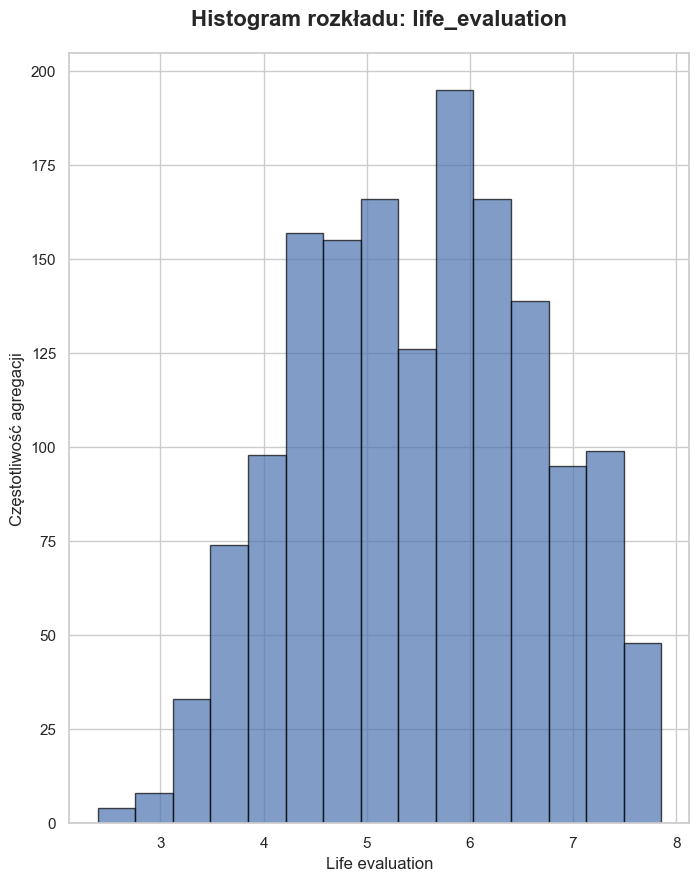

In [28]:
# --- WYKRES 1: ROZKŁAD (Histogram) ---
# Zobaczmy, jak najczęściej kształtuje się wskaźnik szczęścia na świecie.
wykres_histogram(df=df_clean, col='life_evaluation', bins=15)

C:\Users\300538\PycharmProjects\warsztaty-wizualizacja-danych\pipeline\utils.py:483: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


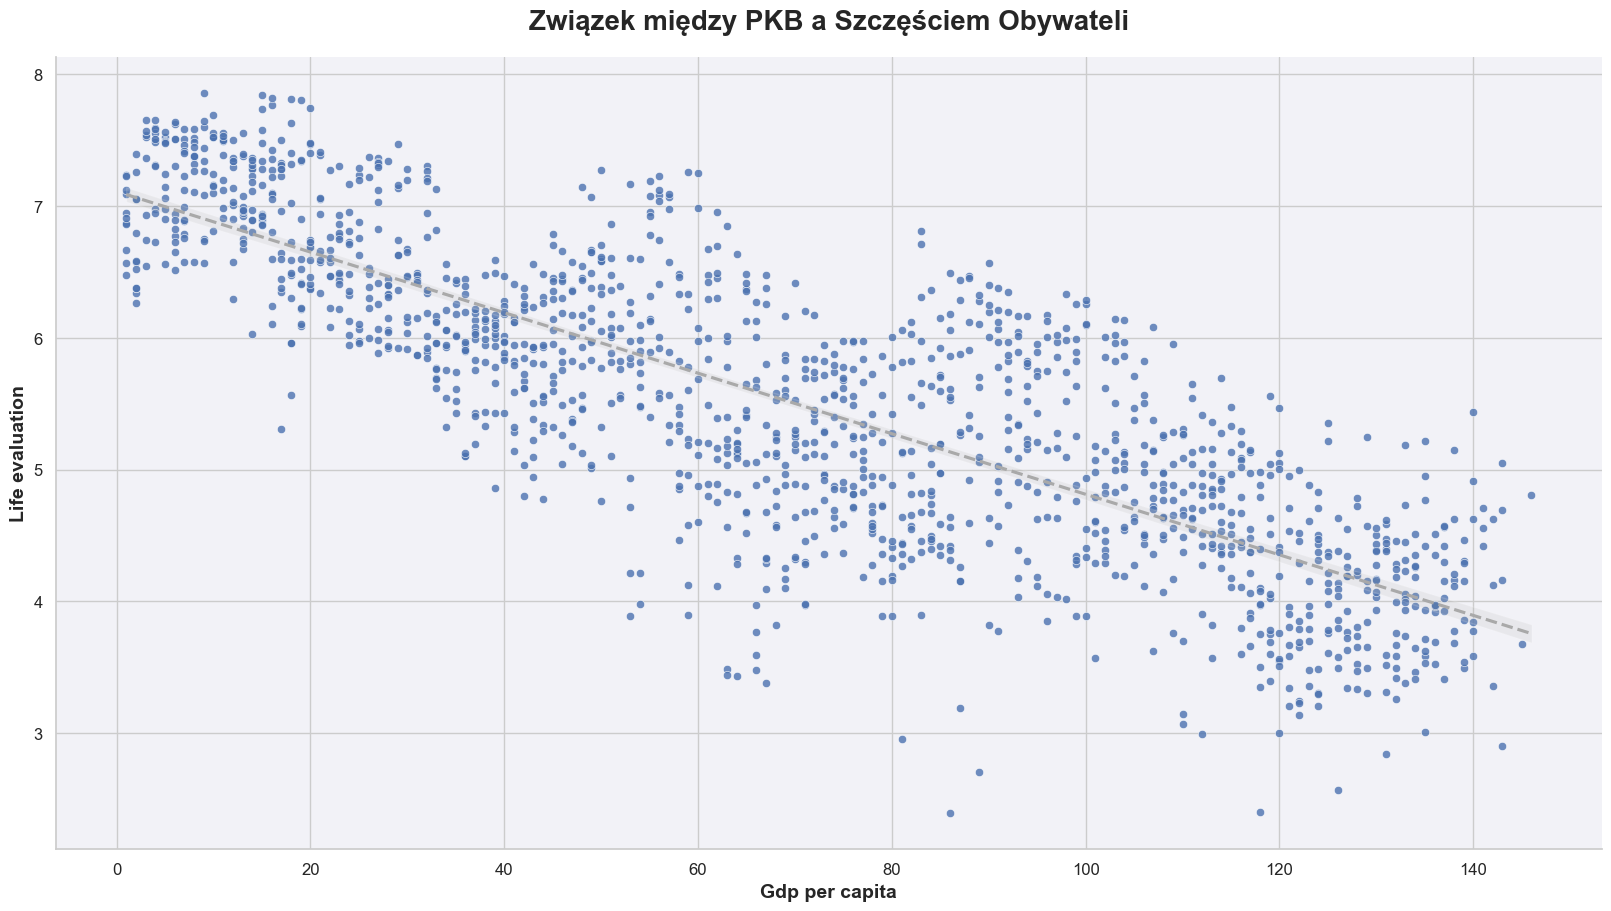

In [29]:
# --- WYKRES 2: ZALEŻNOŚĆ 2 ZMIENNYCH (Punktowy) ---
# Czy bogatsze kraje są szczęśliwsze? (Zależność PKB od Szczęścia)
# Pokazujemy linię trendu, aby wyraźnie to zobaczyć.
wykres_punktowy(
    dane=df_clean, 
    kolumna_1='gdp_per_capita', 
    kolumna_2='life_evaluation', 
    pokaz_trend=True,
    tytul="Związek między PKB a Szczęściem Obywateli"
)

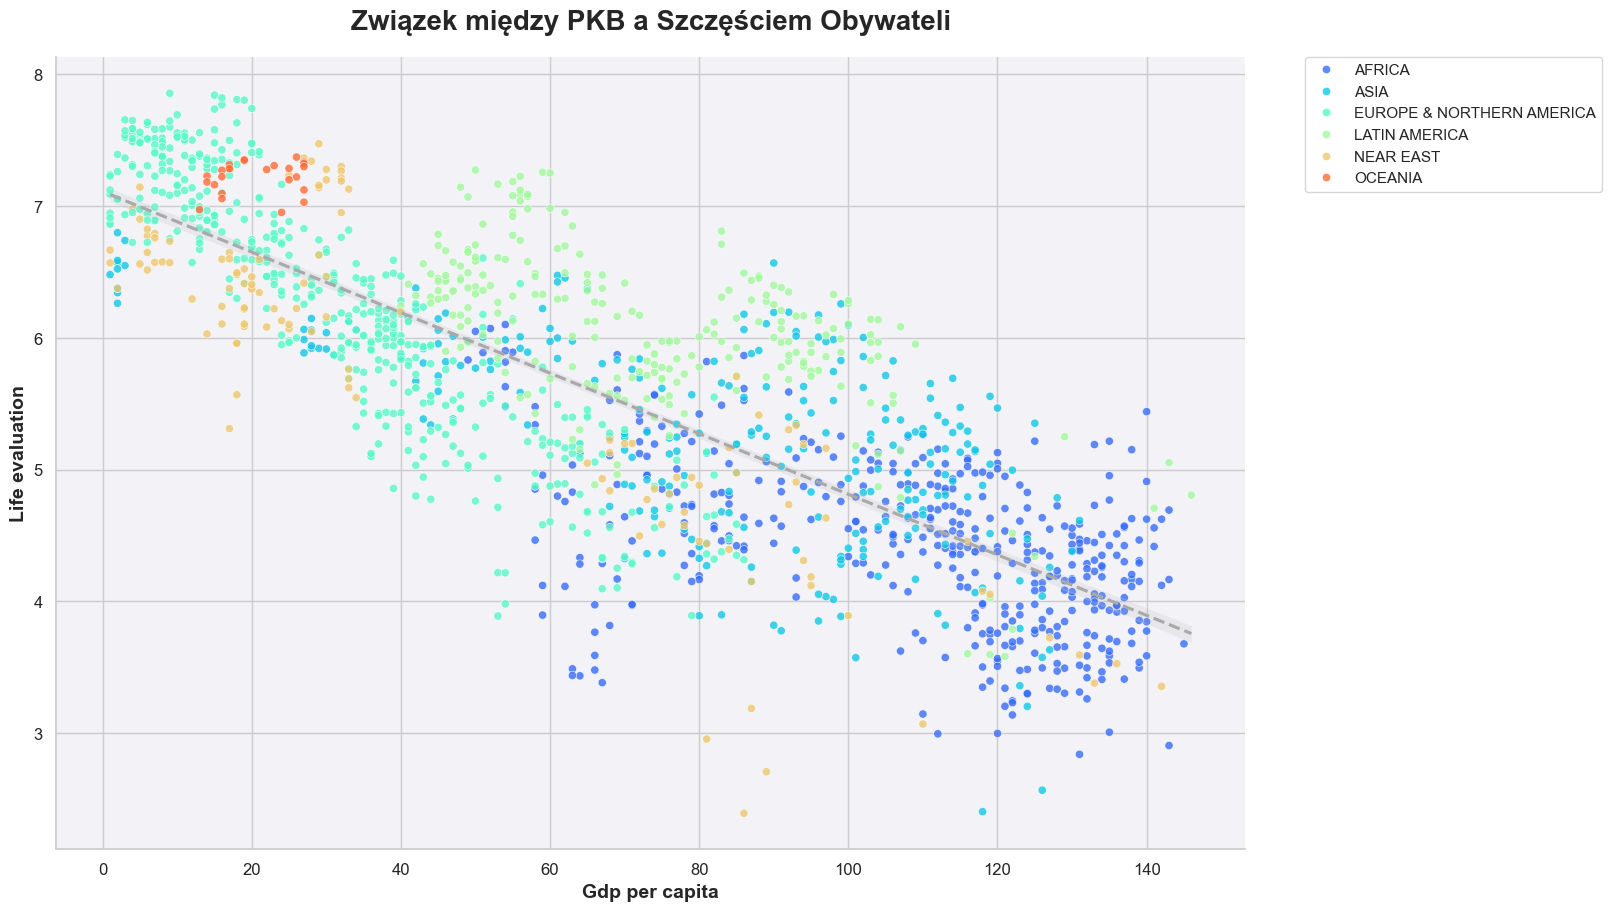

In [35]:
wykres_punktowy(
    dane=df_clean, 
    kolumna_1='gdp_per_capita', 
    kolumna_2='life_evaluation', 
    grupa="region",
    pokaz_trend=True,
    tytul="Związek między PKB a Szczęściem Obywateli"
)

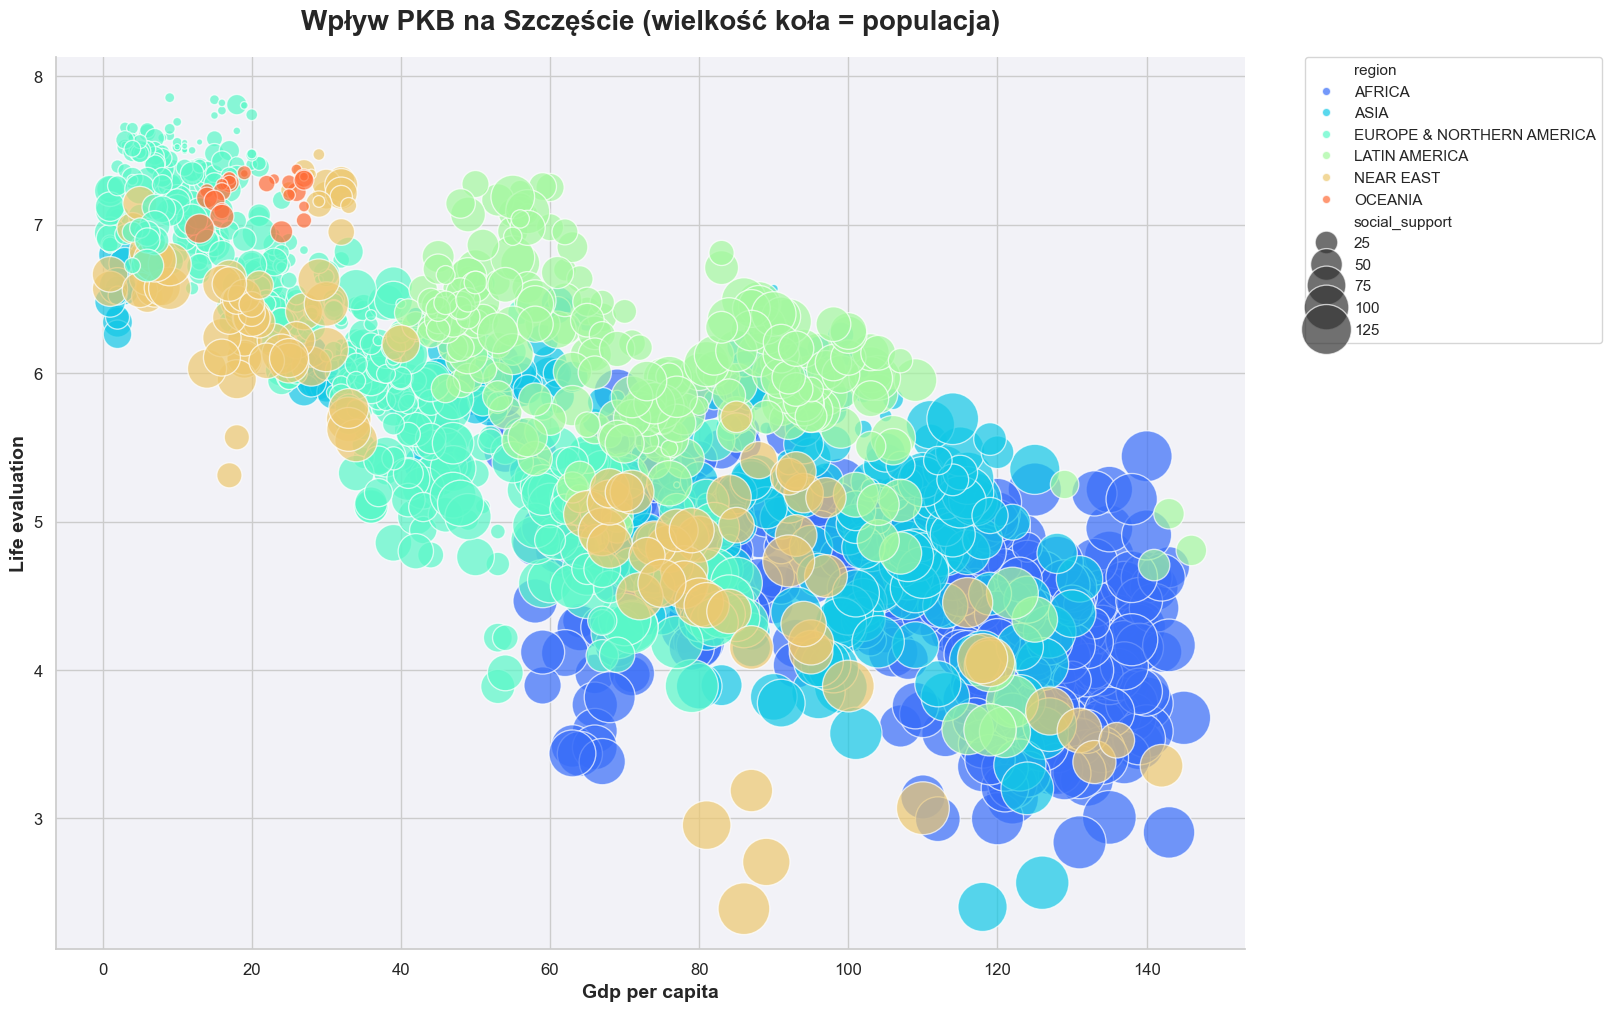

In [38]:
# --- WYKRES 3: ZALEŻNOŚĆ 3 ZMIENNYCH (Bąbelkowy) ---
# Idźmy o krok dalej: X = PKB, Y = Szczęście, Wielkość bąbelka = Populacja, Kolor = Kontynent (region)
wykres_babelkowy(
    dane=df_clean,
    kolumna_x='gdp_per_capita',
    kolumna_y='life_evaluation',
    kolumna_rozmiar='social_support',
    grupa='region',  # Zakładamy, że kolumna z kontynentami to 'region'
    tytul="Wpływ PKB na Szczęście (wielkość koła = populacja)",
    paleta="rainbow"
)

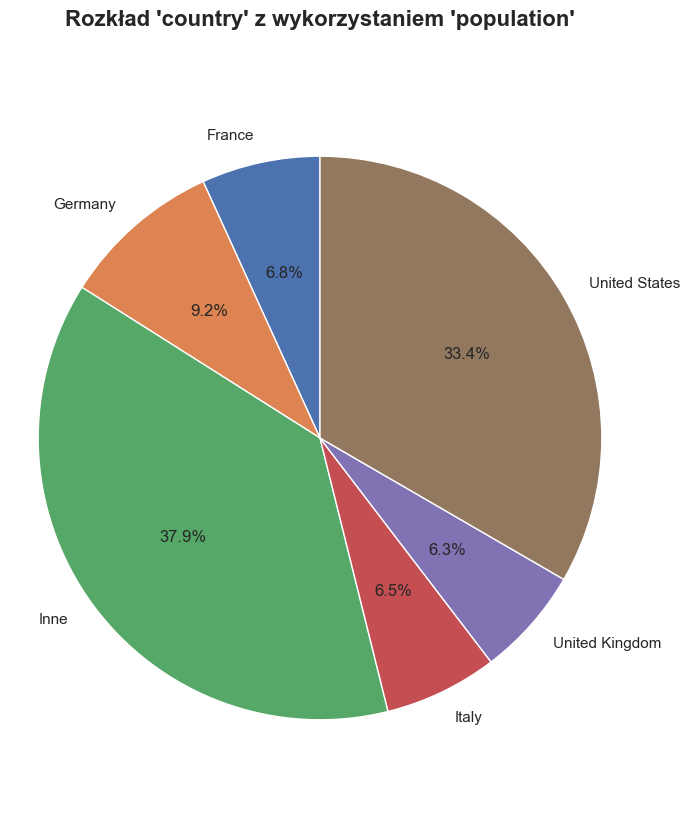

In [41]:
# --- WYKRES 4: PROPORCJE (Kołowy) ---
# Używamy danych z Europy, które przygotowaliśmy wcześniej funkcją top10_wartosci
wykres_kolowy(
    df=df_top_populacja, 
    category_col='country', 
    value_col='population'
)

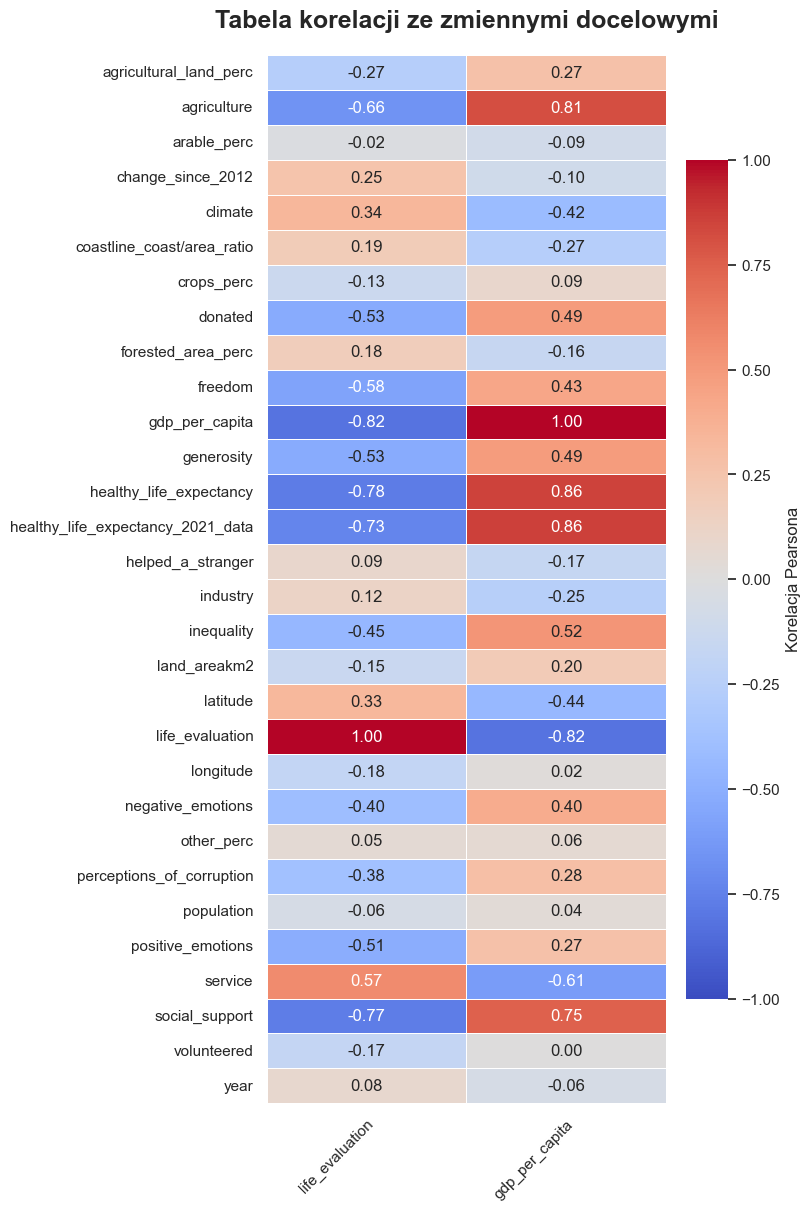

In [44]:
# --- WYKRES 5: POSZUKIWANIE KORELACJI (Macierz ciepła) ---
# Sprawdźmy, które zmienne (np. wskaźnik zbrodni, zdrowia, koszty życia) najmocniej
# wpływają na jakość życia (quality_of_life_index).

# Aby to zrobić, musielibyśmy najpierw połączyć wszystkie te tabele!
# df_wszystko = polacz_dane(...) # Tutaj zadanie dla Was na warsztatach ;)

# Na potrzeby demo sprawdźmy, co wpływa na szczęście w naszym df_clean:
tabela_korelacji(dane=df_clean, kolumny=['life_evaluation', 'gdp_per_capita'])